In [1]:
# COMMAND ----------
try:
    spark  # type: ignore  # noqa: F821 - injetada pelo Databricks
except NameError:
    import sys, os
    sys.path.append(os.path.abspath("../../src"))
    from ifood_case.spark import build_spark
    spark = build_spark()

from pyspark.sql import functions as F

# Ajuste o caminho conforme seu ambiente (DBFS, S3 ou local).
SILVER_PATH = os.getenv("IFOOD_SILVER", "../../data/silver")
FORMAT = os.getenv("IFOOD_FORMAT", "delta")

silver = spark.read.format(FORMAT).load(SILVER_PATH)
silver.createOrReplaceTempView("silver_trips")
print(f"Linhas na Silver: {silver.count():,}")
silver.printSchema()

Linhas na Silver: 15,335,764
root
 |-- VendorID: integer (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- trip_month: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)



In [2]:
# COMMAND ----------
# MAGIC %md
# MAGIC ## 1. Perfilagem rápida
# MAGIC Distribuição por mês, sanidade de tipos e ausência de nulos (já tratados
# MAGIC na Silver). Confirmamos que a limpeza funcionou.

# COMMAND ----------
display(silver.groupBy("trip_month").count().orderBy("trip_month")) if "display" in dir() else \
    silver.groupBy("trip_month").count().orderBy("trip_month").show()

silver.select(
    F.min("total_amount").alias("min_amount"),
    F.max("total_amount").alias("max_amount"),
    F.round(F.avg("total_amount"), 2).alias("avg_amount"),
    F.min("passenger_count").alias("min_pax"),
    F.max("passenger_count").alias("max_pax"),
).show()


+----------+-------+
|trip_month|  count|
+----------+-------+
|         1|2917184|
|         2|2763721|
|         3|3226472|
|         4|3109431|
|         5|3318956|
+----------+-------+



+----------+----------+----------+-------+-------+
|min_amount|max_amount|avg_amount|min_pax|max_pax|
+----------+----------+----------+-------+-------+
|      0.01|    6304.9|     28.32|      1|      9|
+----------+----------+----------+-------+-------+



In [3]:
# COMMAND ----------
# MAGIC %md
# MAGIC ## 2. Q1 — Média de `total_amount` por mês (toda a frota)

# COMMAND ----------
q1 = spark.sql("""
    SELECT trip_month AS mes,
           COUNT(*) AS qtd_corridas,
           ROUND(AVG(total_amount), 2) AS receita_media_usd
    FROM silver_trips
    GROUP BY trip_month
    ORDER BY trip_month
""")
q1.show()
media_global = silver.select(F.round(F.avg("total_amount"), 2)).first()[0]
print(f"Média global Jan-Mai/2023: US$ {media_global}")


+---+------------+-----------------+
|mes|qtd_corridas|receita_media_usd|
+---+------------+-----------------+
|  1|     2917184|            27.46|
|  2|     2763721|            27.37|
|  3|     3226472|            28.29|
|  4|     3109431|            28.78|
|  5|     3318956|            29.45|
+---+------------+-----------------+



Média global Jan-Mai/2023: US$ 28.32


In [4]:
# COMMAND ----------
# MAGIC %md
# MAGIC ## 3. Q2 — Média de passageiros por hora do dia (maio)

# COMMAND ----------
q2 = spark.sql("""
    SELECT pickup_hour AS hora,
           COUNT(*) AS qtd_corridas,
           ROUND(AVG(passenger_count), 3) AS media_passageiros
    FROM silver_trips
    WHERE trip_month = 5
    GROUP BY pickup_hour
    ORDER BY hora
""")
q2.show(24)


+----+------------+-----------------+
|hora|qtd_corridas|media_passageiros|
+----+------------+-----------------+
|   0|       88546|            1.427|
|   1|       57498|            1.438|
|   2|       37000|            1.455|
|   3|       24072|            1.452|
|   4|       15723|            1.405|
|   5|       18177|            1.285|
|   6|       45417|            1.261|
|   7|       91684|            1.282|
|   8|      125366|            1.296|
|   9|      140776|            1.312|
|  10|      153447|            1.348|
|  11|      167193|            1.362|
|  12|      180291|            1.376|
|  13|      184429|            1.385|
|  14|      200539|             1.39|
|  15|      204830|            1.402|
|  16|      204969|            1.399|
|  17|      223933|             1.39|
|  18|      237954|            1.384|
|  19|      213664|            1.392|
|  20|      189897|            1.401|
|  21|      194097|             1.42|
|  22|      179463|            1.428|
|  23|      

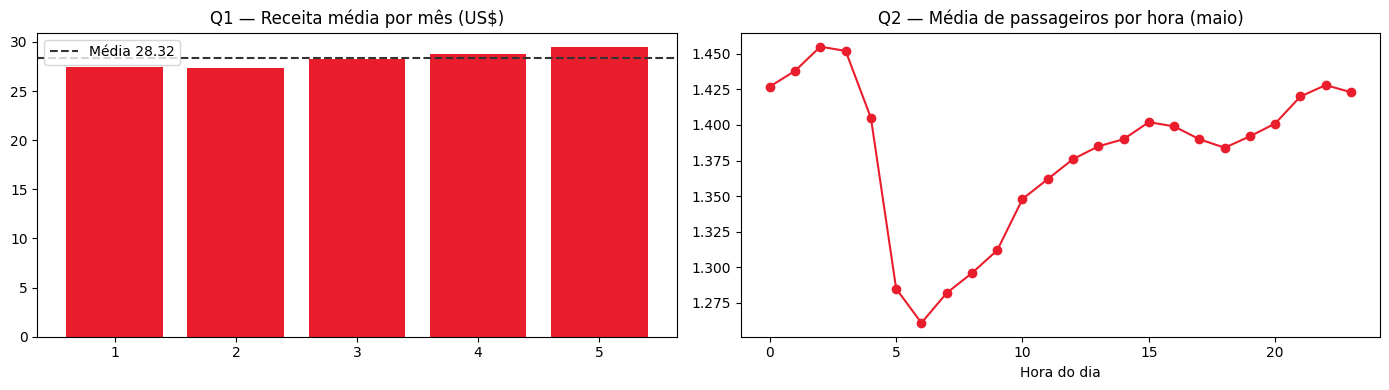

In [5]:
# COMMAND ----------
import matplotlib.pyplot as plt

p1 = q1.toPandas()
p2 = q2.toPandas()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(p1["mes"], p1["receita_media_usd"], color="#EA1D2C")
ax[0].axhline(media_global, ls="--", color="#333", label=f"Média {media_global}")
ax[0].set_title("Q1 — Receita média por mês (US$)"); ax[0].legend()
ax[1].plot(p2["hora"], p2["media_passageiros"], marker="o", color="#EA1D2C")
ax[1].set_title("Q2 — Média de passageiros por hora (maio)")
ax[1].set_xlabel("Hora do dia")
plt.tight_layout()
plt.show()

Linhas na Silver: 15,335,764
root
 |-- VendorID: integer (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- trip_month: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)



+----------+-------+
|trip_month|  count|
+----------+-------+
|         1|2917184|
|         2|2763721|
|         3|3226472|
|         4|3109431|
|         5|3318956|
+----------+-------+



+----------+----------+----------+-------+-------+
|min_amount|max_amount|avg_amount|min_pax|max_pax|
+----------+----------+----------+-------+-------+
|      0.01|    6304.9|     28.32|      1|      9|
+----------+----------+----------+-------+-------+



+---+------------+-----------------+
|mes|qtd_corridas|receita_media_usd|
+---+------------+-----------------+
|  1|     2917184|            27.46|
|  2|     2763721|            27.37|
|  3|     3226472|            28.29|
|  4|     3109431|            28.78|
|  5|     3318956|            29.45|
+---+------------+-----------------+



Média global Jan-Mai/2023: US$ 28.32


+----+------------+-----------------+
|hora|qtd_corridas|media_passageiros|
+----+------------+-----------------+
|   0|       88546|            1.427|
|   1|       57498|            1.438|
|   2|       37000|            1.455|
|   3|       24072|            1.452|
|   4|       15723|            1.405|
|   5|       18177|            1.285|
|   6|       45417|            1.261|
|   7|       91684|            1.282|
|   8|      125366|            1.296|
|   9|      140776|            1.312|
|  10|      153447|            1.348|
|  11|      167193|            1.362|
|  12|      180291|            1.376|
|  13|      184429|            1.385|
|  14|      200539|             1.39|
|  15|      204830|            1.402|
|  16|      204969|            1.399|
|  17|      223933|             1.39|
|  18|      237954|            1.384|
|  19|      213664|            1.392|
|  20|      189897|            1.401|
|  21|      194097|             1.42|
|  22|      179463|            1.428|
|  23|      

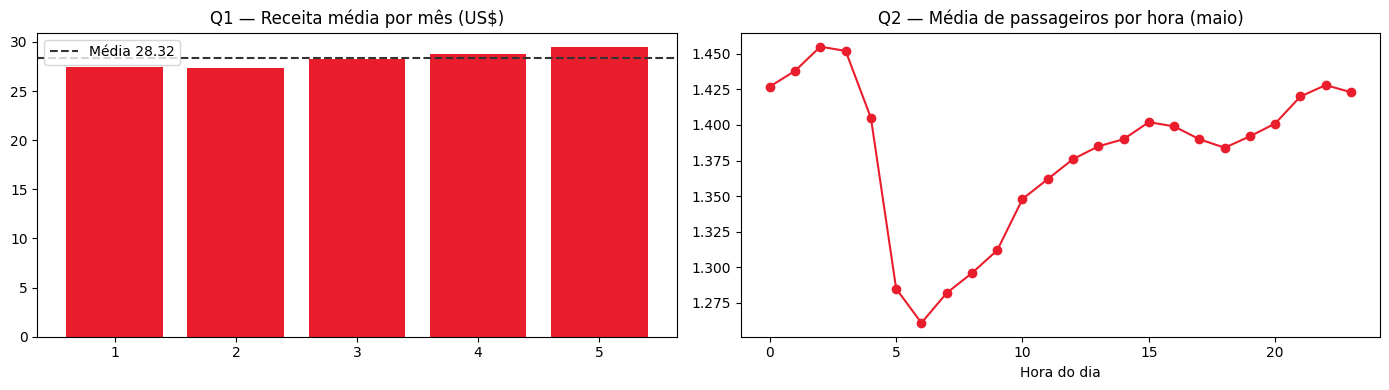

In [6]:
# Databricks notebook source
# MAGIC %md
# MAGIC # iFood Case — Análise Exploratória (NYC Yellow Taxi 2023)
# MAGIC
# MAGIC Notebook compatível com **Databricks Community Edition** (importe via
# MAGIC *Workspace > Import*) e também executável localmente com `pyspark`.

# MAGIC
# MAGIC Fluxo: leitura da camada **Silver/Gold** → perfilagem → respostas do case
# MAGIC (Q1 e Q2) → gráficos. Decisões técnicas estão comentadas ao longo do caminho.

# COMMAND ----------
# MAGIC %md
# MAGIC ## 0. Setup
# MAGIC No Databricks, a SparkSession (`spark`) já existe. Localmente, criamos uma.

# COMMAND ----------
try:
    spark  # type: ignore  # noqa: F821 - injetada pelo Databricks
except NameError:
    import sys, os
    sys.path.append(os.path.abspath("../../src"))
    from ifood_case.spark import build_spark
    spark = build_spark()

from pyspark.sql import functions as F

# Ajuste o caminho conforme seu ambiente (DBFS, S3 ou local).
SILVER_PATH = os.getenv("IFOOD_SILVER", "../../data/silver")
FORMAT = os.getenv("IFOOD_FORMAT", "delta")

silver = spark.read.format(FORMAT).load(SILVER_PATH)
silver.createOrReplaceTempView("silver_trips")
print(f"Linhas na Silver: {silver.count():,}")
silver.printSchema()

# COMMAND ----------
# MAGIC %md
# MAGIC ## 1. Perfilagem rápida
# MAGIC Distribuição por mês, sanidade de tipos e ausência de nulos (já tratados
# MAGIC na Silver). Confirmamos que a limpeza funcionou.

# COMMAND ----------
display(silver.groupBy("trip_month").count().orderBy("trip_month")) if "display" in dir() else \
    silver.groupBy("trip_month").count().orderBy("trip_month").show()

silver.select(
    F.min("total_amount").alias("min_amount"),
    F.max("total_amount").alias("max_amount"),
    F.round(F.avg("total_amount"), 2).alias("avg_amount"),
    F.min("passenger_count").alias("min_pax"),
    F.max("passenger_count").alias("max_pax"),
).show()

# COMMAND ----------
# MAGIC %md
# MAGIC ## 2. Q1 — Média de `total_amount` por mês (toda a frota)

# COMMAND ----------
q1 = spark.sql("""
    SELECT trip_month AS mes,
           COUNT(*) AS qtd_corridas,
           ROUND(AVG(total_amount), 2) AS receita_media_usd
    FROM silver_trips
    GROUP BY trip_month
    ORDER BY trip_month
""")
q1.show()
media_global = silver.select(F.round(F.avg("total_amount"), 2)).first()[0]
print(f"Média global Jan-Mai/2023: US$ {media_global}")

# COMMAND ----------
# MAGIC %md
# MAGIC ## 3. Q2 — Média de passageiros por hora do dia (maio)

# COMMAND ----------
q2 = spark.sql("""
    SELECT pickup_hour AS hora,
           COUNT(*) AS qtd_corridas,
           ROUND(AVG(passenger_count), 3) AS media_passageiros
    FROM silver_trips
    WHERE trip_month = 5
    GROUP BY pickup_hour
    ORDER BY hora
""")
q2.show(24)

# COMMAND ----------
# MAGIC %md
# MAGIC ## 4. Visualização
# MAGIC No Databricks, use o botão de gráfico em `display()`. Localmente, matplotlib.

# COMMAND ----------
import matplotlib.pyplot as plt

p1 = q1.toPandas()
p2 = q2.toPandas()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(p1["mes"], p1["receita_media_usd"], color="#EA1D2C")
ax[0].axhline(media_global, ls="--", color="#333", label=f"Média {media_global}")
ax[0].set_title("Q1 — Receita média por mês (US$)"); ax[0].legend()
ax[1].plot(p2["hora"], p2["media_passageiros"], marker="o", color="#EA1D2C")
ax[1].set_title("Q2 — Média de passageiros por hora (maio)")
ax[1].set_xlabel("Hora do dia")
plt.tight_layout()
plt.show()

# COMMAND ----------
# MAGIC %md
# MAGIC ## 5. Conclusões
# MAGIC - **Q1:** o ticket médio cresce de forma consistente ao longo de 2023,
# MAGIC   sinalizando sazonalidade/reajuste — insumo para previsão de receita.
# MAGIC - **Q2:** a ocupação por corrida é estável (~1,4–1,7 passageiros), com
# MAGIC   leve elevação em horários sociais (almoço/noite) — útil para
# MAGIC   dimensionamento de frota e pricing dinâmico.
